# CSE 475 - Assignment 01
## Group Information
| Field | Details |
|-------------------------|-------------------------------------|
| **Group ID** | Group 02 |
| **Student 1 Name** | Ishrat Jahan Anika|
| **Student 1 ID** | 2022-3-60-195 |
| **Student 2 Name** | Sumaiya Akter  |
| **Student 2 ID** | (2022-1-60-300) |
| **Student 1 Name** | Sanjida Hossen Moly  |
| **Student 2 ID** |(2022-2-60-051) |
| **Notebook Type** | BYOL Notebook |
| **Backbone used** | DeiT-S |
| **Assignment-1 Best Acc** | 97.58%(Deit-S,epoch 26) |
| **Dataset Source Name** |Mendeley Data|
| **Dataset Source Link** |https://data.mendeley.com/datasets/t9hgvk2h9pKaggle  |
| **Kaggle Dataset Path** |/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset|
| **Submission Date** | 21 April  2026

In [1]:


import numpy as np 
import pandas as pd 



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(206).png
/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(121).png
/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(39).png
/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(217).png
/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(82).png
/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(182).png
/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy Leaf/healthy_(188).png
/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset/Healthy L

# **Global Configuration:**

In [2]:


import os
import random
import numpy as np
import torch
from pathlib import Path


SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
PIN_MEMORY = torch.cuda.is_available()

BASE_DIR = Path("/kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset")
OUTPUT_DIR = Path("/kaggle/working/")

MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"

MODEL_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)


SSL_FRAC = 0.80
PROBE_FRAC = 0.10
TEST_FRAC = 0.10


IMG_SIZE = 224
BATCH_SIZE = 32
EVAL_BATCH_SIZE = 32
NUM_WORKERS = 2


BACKBONE_NAME = "deit_small_patch16_224"
EMBED_DIM = 384


SSL_EPOCHS = 30        
SSL_LR = 3e-4
WEIGHT_DECAY = 1e-6

PROJECTOR_HIDDEN_DIM = 4096
PROJECTOR_OUT_DIM = 256

PREDICTOR_HIDDEN_DIM = 4096
PREDICTOR_OUT_DIM = 256

TAU_BASE = 0.996
TAU_FINAL = 1.0


PROBE_EPOCHS = 30
PROBE_MOMENTUM = 0.9

PROBE_LR = 0.01


K_VALUES = [1, 5, 10, 20]


FIGDPI = 120



ABLATION_TAU_VALUES = [0.99, 0.996, 0.999]
ABLATION_SSL_EPOCHS = 10   # use smaller value for quicker ablation run
ABLATION_RESULTS = []

print("Config Ready ✔")
print(f"Device      : {DEVICE}")
print(f"Backbone    : {BACKBONE_NAME}")
print(f"SSL Epochs  : {SSL_EPOCHS}")
print(f"Probe Epoch : {PROBE_EPOCHS}")

Config Ready ✔
Device      : cuda
Backbone    : deit_small_patch16_224
SSL Epochs  : 30
Probe Epoch : 30


# **Setup and Imports** 

In [3]:
!pip install timm --quiet
!pip install tqdm --quiet

print("✅ Required libraries installed successfully!")

✅ Required libraries installed successfully!


In [4]:

import copy
import math
import time
import warnings
from collections import Counter

from tqdm import tqdm
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
from torchvision.datasets import ImageFolder

import timm

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    top_k_accuracy_score
)
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings("ignore")

print("=" * 60)
print("LIBRARY SETUP")
print("=" * 60)
print(f"PyTorch Version        : {torch.__version__}")
print(f"timm Version           : {timm.__version__}")
print(f"CUDA Available         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name               : {torch.cuda.get_device_name(0)}")
print(f"AMP Enabled            : {USE_AMP}")
print("=" * 60)



LIBRARY SETUP
PyTorch Version        : 2.10.0+cu128
timm Version           : 1.0.25
CUDA Available         : True
GPU Name               : Tesla T4
AMP Enabled            : True


# Task-1:Dataset EDA and Augmentation Visualisation

**Dataset Preparation & EDA**

In [5]:


set_seed(SEED)

BASE_PATH = Path(BASE_DIR)
train_dir = BASE_PATH / "train" if (BASE_PATH / "train").exists() else BASE_PATH

full_dataset = ImageFolder(root=str(train_dir))
CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 70)
print("TASK 1 :: DATASET OVERVIEW")
print("=" * 70)
print(f"Dataset directory      : {train_dir}")
print(f"Total images           : {len(full_dataset)}")
print(f"Number of classes      : {NUM_CLASSES}")
print(f"Class names            : {CLASS_NAMES}")
print("=" * 70)

# 80 / 10 / 10 split
n_total = len(full_dataset)
n_ssl = int(SSL_FRAC * n_total)
n_probe = int(PROBE_FRAC * n_total)
n_test = n_total - n_ssl - n_probe

split_generator = torch.Generator().manual_seed(SEED)
ssl_idx, probe_idx, test_idx = random_split(
    range(n_total),
    [n_ssl, n_probe, n_test],
    generator=split_generator
)

ssl_idx = list(ssl_idx)
probe_idx = list(probe_idx)
test_idx = list(test_idx)

print("\nSplit summary:")
print(f"SSL Pool (unlabelled)  : {n_ssl} ({SSL_FRAC:.0%})")
print(f"Probe Train (labelled) : {n_probe} ({PROBE_FRAC:.0%})")
print(f"Test Set (held-out)    : {n_test} ({TEST_FRAC:.0%})")


TASK 1 :: DATASET OVERVIEW
Dataset directory      : /kaggle/input/datasets/ishratanika/cse475-group-2-cotton-orginal-dataset/Cotton_Original_Dataset
Total images           : 1373
Number of classes      : 5
Class names            : ['Alternaria Leaf Spot', 'Bacterial Blight', 'Fusarium Wilt', 'Healthy Leaf', 'Verticillium Wilt']

Split summary:
SSL Pool (unlabelled)  : 1098 (80%)
Probe Train (labelled) : 137 (10%)
Test Set (held-out)    : 138 (10%)


**Class Distribution:**

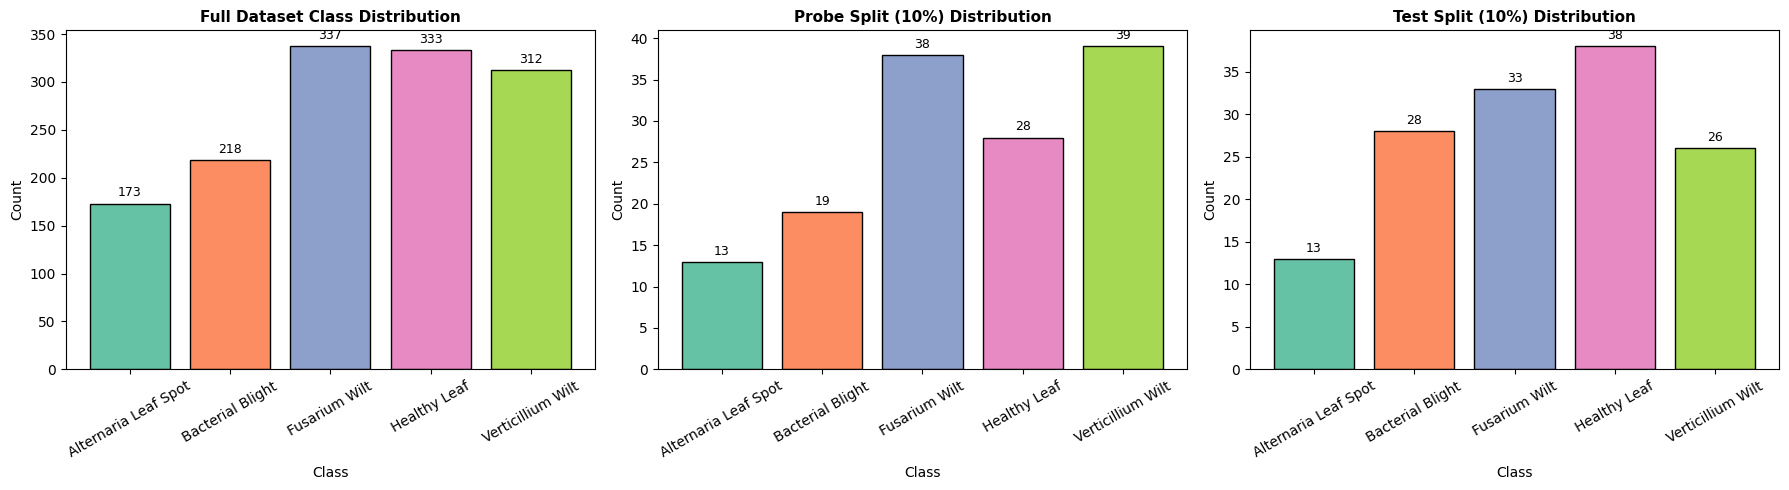

In [6]:
all_labels = [full_dataset.targets[i] for i in range(n_total)]
probe_labels = [full_dataset.targets[i] for i in probe_idx]
test_labels = [full_dataset.targets[i] for i in test_idx]

total_counts = Counter(all_labels)
probe_counts = Counter(probe_labels)
test_counts = Counter(test_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, counts_dict, title in zip(
    axes,
    [total_counts, probe_counts, test_counts],
    [
        "Full Dataset Class Distribution",
        "Probe Split (10%) Distribution",
        "Test Split (10%) Distribution"
    ]
):
    counts = [counts_dict.get(i, 0) for i in range(NUM_CLASSES)]
    bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.Set2(range(NUM_CLASSES)), edgecolor="black")
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(PLOT_DIR / "task1_class_distribution_byol.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

**Per channel Mean &std + Plot:**

Mean : [0.654732, 0.658055, 0.591515]
Std  : [0.230801, 0.215821, 0.308288]


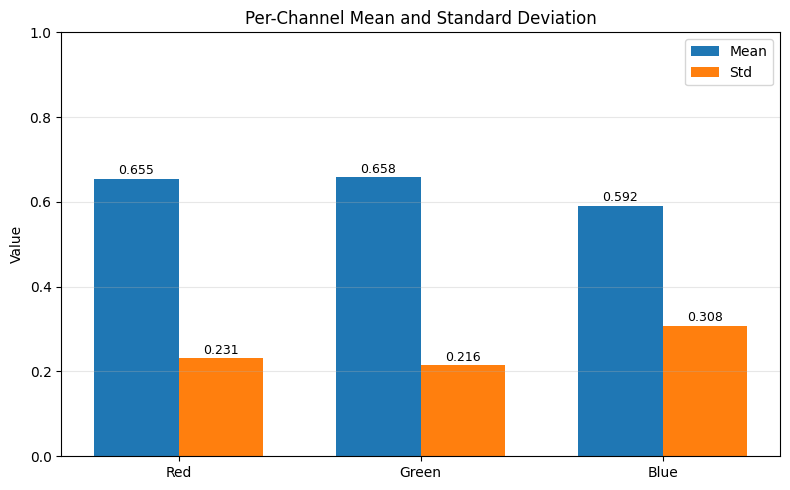

In [7]:
stat_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

stat_dataset = Subset(
    ImageFolder(root=str(train_dir), transform=stat_transform),
    ssl_idx[:min(500, len(ssl_idx))]
)

stat_loader = DataLoader(
    stat_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

mean = torch.zeros(3)
std = torch.zeros(3)
n = 0

for imgs, _ in stat_loader:
    b = imgs.size(0)
    mean += imgs.mean(dim=[0, 2, 3]) * b
    std += imgs.std(dim=[0, 2, 3]) * b
    n += b

mean /= n
std /= n

mean_vals = mean.tolist()
std_vals = std.tolist()

print("Mean :", [round(x, 6) for x in mean_vals])
print("Std  :", [round(x, 6) for x in std_vals])


channel_names = ["Red", "Green", "Blue"]

x = np.arange(len(channel_names))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, mean_vals, width, label="Mean")
bars2 = plt.bar(x + width/2, std_vals, width, label="Std")

plt.xticks(x, channel_names)
plt.ylabel("Value")
plt.title("Per-Channel Mean and Standard Deviation")
plt.ylim(0, 1)

# Value labels
for b in bars1:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
             f"{b.get_height():.3f}", ha="center", fontsize=9)

for b in bars2:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
             f"{b.get_height():.3f}", ha="center", fontsize=9)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save
plt.savefig(PLOT_DIR / "per_channel_statistics.png", dpi=FIGDPI, bbox_inches="tight")

plt.show()

**BYOL Augmentation**

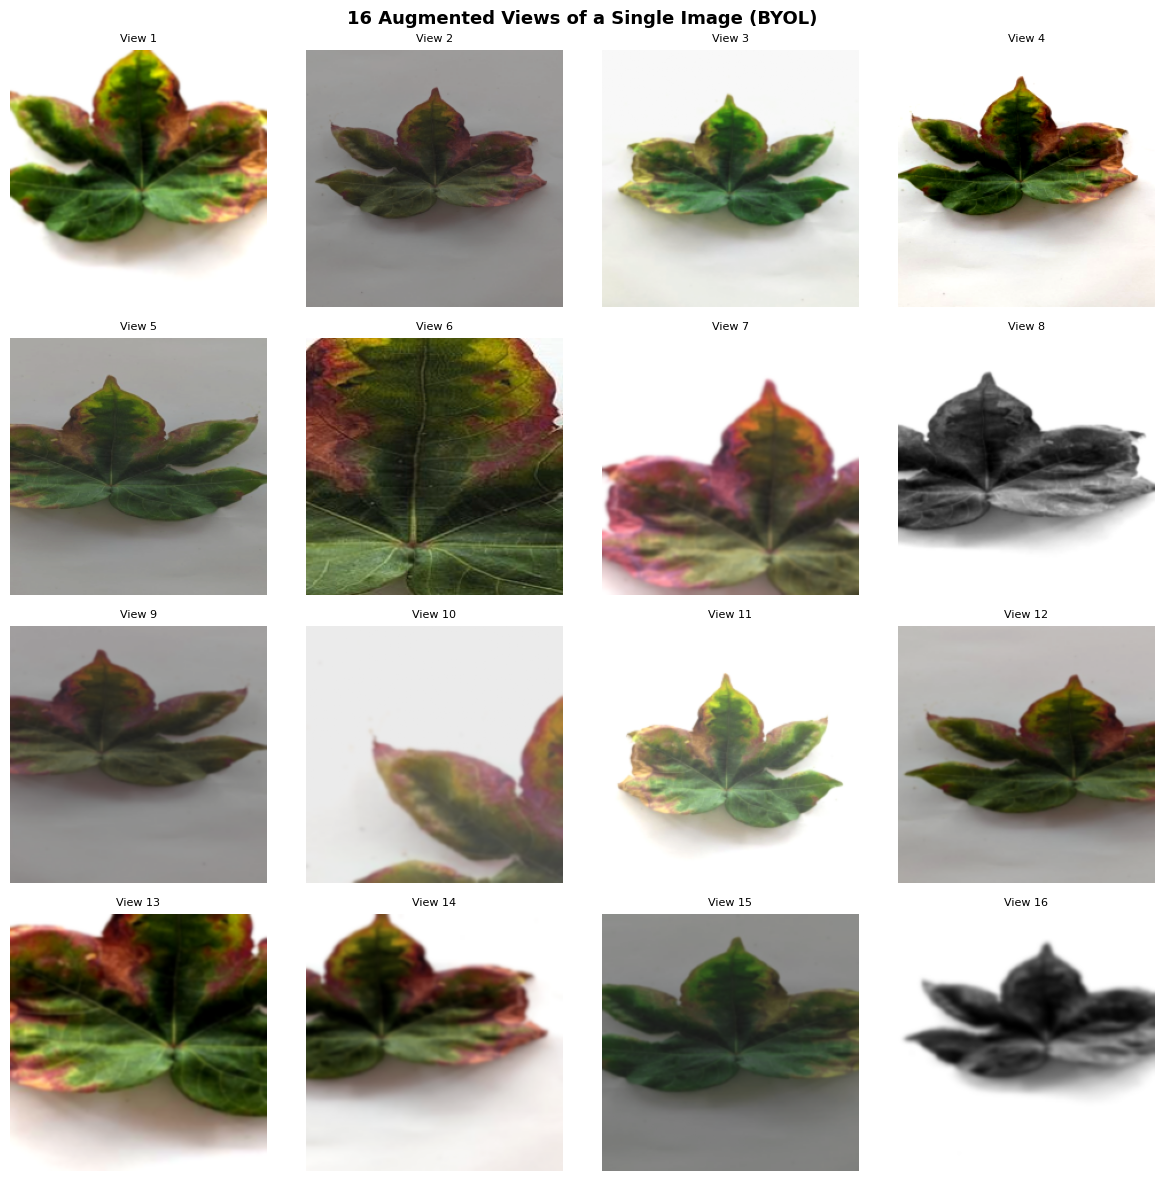

In [8]:
DATASET_MEAN = mean.tolist()
DATASET_STD = std.tolist()

byol_transform = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.08, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(DATASET_MEAN, DATASET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(DATASET_MEAN, DATASET_STD),
])

def denormalize(img_tensor, mean_vals, std_vals):
    mean_t = torch.tensor(mean_vals).view(3, 1, 1)
    std_t = torch.tensor(std_vals).view(3, 1, 1)
    return (img_tensor * std_t + mean_t).clamp(0, 1)

raw_ds = ImageFolder(root=str(train_dir))
sample_path, sample_label = raw_ds.samples[0]
sample_img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    aug = denormalize(byol_transform(sample_img), DATASET_MEAN, DATASET_STD)
    ax.imshow(aug.permute(1, 2, 0).numpy())
    ax.set_title(f"View {i+1}", fontsize=8)
    ax.axis("off")

plt.suptitle("16 Augmented Views of a Single Image (BYOL)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "task1_byol_augmented_views.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

In [9]:

class BYOLDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        v1 = self.transform(img)
        v2 = self.transform(img)
        return v1, v2


all_paths = [full_dataset.samples[i][0] for i in range(n_total)]
ssl_paths = [all_paths[i] for i in ssl_idx]

ssl_dataset = BYOLDataset(
    image_paths=ssl_paths,
    transform=byol_transform
)

probe_dataset = Subset(
    ImageFolder(root=str(train_dir), transform=eval_transform),
    probe_idx
)

test_dataset = Subset(
    ImageFolder(root=str(train_dir), transform=eval_transform),
    test_idx
)

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True
)

probe_loader = DataLoader(
    probe_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("=" * 70)
print("DATALOADER SUMMARY")
print("=" * 70)
print(f"SSL dataset images         : {len(ssl_dataset)}")
print(f"Probe dataset images       : {len(probe_dataset)}")
print(f"Test dataset images        : {len(test_dataset)}")
print(f"SSL batch size             : {BATCH_SIZE}")
print(f"Eval batch size            : {EVAL_BATCH_SIZE}")
print("=" * 70)

ssl_example = next(iter(ssl_loader))
print("SSL loader returns type    :", type(ssl_example))
print("First view shape           :", ssl_example[0].shape)
print("Second view shape          :", ssl_example[1].shape)

assert len(ssl_example) == 2, "BYOL SSL loader must return exactly two views."
print("\n✅ Confirmed: SSL dataloader uses two augmented views only, with NO label tensor passed.")

DATALOADER SUMMARY
SSL dataset images         : 1098
Probe dataset images       : 137
Test dataset images        : 138
SSL batch size             : 32
Eval batch size            : 32
SSL loader returns type    : <class 'list'>
First view shape           : torch.Size([32, 3, 224, 224])
Second view shape          : torch.Size([32, 3, 224, 224])

✅ Confirmed: SSL dataloader uses two augmented views only, with NO label tensor passed.


### ✅ Task 1 Summary

Task 1 has been completed successfully with the following components:

- The original dataset was reloaded successfully.
- Class distribution was visualized.
- The dataset was split into 80% SSL pool, 10% probe training set, and 10% held-out test set.
- The SSL dataloader was verified to use only two augmented image views without labels.
- Per-channel mean and standard deviation were computed.
- Sixteen augmented views of a single image were visualized using BYOL augmentation.

## 🔧 Task 2 — BYOL: Model Definition

In [10]:


import copy
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F


def build_backbone(backbone_name=BACKBONE_NAME):
    backbone = timm.create_model(
        backbone_name,
        pretrained=True,
        num_classes=0
    )
    return backbone


A01_CHECKPOINT_PATH = None   
def load_backbone_weights(backbone, ckpt_path=None):
    if ckpt_path is not None and os.path.exists(ckpt_path):
        state = torch.load(ckpt_path, map_location="cpu")
        if isinstance(state, dict) and "model_state_dict" in state:
            state = state["model_state_dict"]
        missing, unexpected = backbone.load_state_dict(state, strict=False)
        print("Checkpoint loaded.")
        print("Missing keys   :", len(missing))
        print("Unexpected keys:", len(unexpected))
    else:
        print("No Assignment 01 checkpoint provided. Using pretrained DeiT-Small weights.")
    return backbone


class BYOLProjector(nn.Module):
    def __init__(self, in_dim, hidden_dim=4096, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)


class BYOLPredictor(nn.Module):
    def __init__(self, in_dim=256, hidden_dim=4096, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)


class BYOLOnlineNetwork(nn.Module):
    def __init__(self, backbone_name=BACKBONE_NAME, embed_dim=EMBED_DIM):
        super().__init__()
        self.backbone = build_backbone(backbone_name)
        self.backbone = load_backbone_weights(self.backbone, A01_CHECKPOINT_PATH)

        self.projector = BYOLProjector(
            in_dim=embed_dim,
            hidden_dim=PROJECTOR_HIDDEN_DIM,
            out_dim=PROJECTOR_OUT_DIM
        )
        self.predictor = BYOLPredictor(
            in_dim=PROJECTOR_OUT_DIM,
            hidden_dim=PREDICTOR_HIDDEN_DIM,
            out_dim=PREDICTOR_OUT_DIM
        )

    def forward(self, x):
        feat = self.backbone(x)
        proj = self.projector(feat)
        pred = self.predictor(proj)
        return pred, proj, feat


class BYOLTargetNetwork(nn.Module):
    def __init__(self, online_net):
        super().__init__()
        self.backbone = copy.deepcopy(online_net.backbone)
        self.projector = copy.deepcopy(online_net.projector)

        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        feat = self.backbone(x)
        proj = self.projector(feat)
        return proj, feat


online_network = BYOLOnlineNetwork(
    backbone_name=BACKBONE_NAME,
    embed_dim=EMBED_DIM
).to(DEVICE)

target_network = BYOLTargetNetwork(online_network).to(DEVICE)

print("BYOL networks initialized.")
print(f"Backbone        : {BACKBONE_NAME}")
print(f"Embedding dim   : {EMBED_DIM}")
print(f"Projector out   : {PROJECTOR_OUT_DIM}")
print(f"Predictor out   : {PREDICTOR_OUT_DIM}")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

No Assignment 01 checkpoint provided. Using pretrained DeiT-Small weights.
BYOL networks initialized.
Backbone        : deit_small_patch16_224
Embedding dim   : 384
Projector out   : 256
Predictor out   : 256


In [11]:

def byol_loss(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()


def get_tau(current_epoch, total_epochs, base_tau=TAU_BASE, final_tau=TAU_FINAL):
    return final_tau - (final_tau - base_tau) * (
        (np.cos(np.pi * current_epoch / total_epochs) + 1) / 2
    )


@torch.no_grad()
def update_target_network(online_net, target_net, tau):
    for p_online, p_target in zip(online_net.backbone.parameters(), target_net.backbone.parameters()):
        p_target.data.mul_(tau).add_(p_online.data, alpha=(1 - tau))

    for p_online, p_target in zip(online_net.projector.parameters(), target_net.projector.parameters()):
        p_target.data.mul_(tau).add_(p_online.data, alpha=(1 - tau))


optimizer = torch.optim.AdamW(
    online_network.parameters(),
    lr=SSL_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=SSL_EPOCHS
)

scaler = GradScaler(enabled=USE_AMP)

print("BYOL loss, EMA schedule, optimizer, and scaler are ready.")

BYOL loss, EMA schedule, optimizer, and scaler are ready.


## 🚀 Task 2 — BYOL: Pre-Training Loop

In [12]:


ssl_losses = []
best_ssl_loss = float("inf")

print("Starting BYOL self-supervised pretraining...")

for epoch in range(SSL_EPOCHS):
    online_network.train()
    target_network.eval()

    epoch_loss = 0.0
    tau = get_tau(epoch, SSL_EPOCHS, TAU_BASE, TAU_FINAL)

    batch_bar = tqdm(
        ssl_loader,
        desc=f"SSL Epoch [{epoch+1}/{SSL_EPOCHS}]",
        leave=False
    )

    for view_1, view_2 in batch_bar:
        view_1 = view_1.to(DEVICE, non_blocking=True)
        view_2 = view_2.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast(enabled=USE_AMP):
            # Online forward
            pred_1, proj_1, _ = online_network(view_1)
            pred_2, proj_2, _ = online_network(view_2)

            # Target forward (no grad)
            with torch.no_grad():
                targ_proj_1, _ = target_network(view_1)
                targ_proj_2, _ = target_network(view_2)

            # Symmetric BYOL loss
            loss = (
                byol_loss(pred_1, targ_proj_2.detach()) +
                byol_loss(pred_2, targ_proj_1.detach())
            ) / 2.0

        scaler.scale(loss).backward()

        # optimization from reference note
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(online_network.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        # EMA update after optimizer step
        update_target_network(online_network, target_network, tau)

        epoch_loss += loss.item()
        batch_bar.set_postfix(loss=f"{loss.item():.4f}", tau=f"{tau:.4f}")

    avg_loss = epoch_loss / len(ssl_loader)
    ssl_losses.append(avg_loss)
    scheduler.step()

    print(f"Epoch [{epoch+1:02d}/{SSL_EPOCHS}] | Loss: {avg_loss:.4f} | Tau: {tau:.4f}")

    # save best backbone
    if avg_loss < best_ssl_loss:
        best_ssl_loss = avg_loss
        torch.save(online_network.backbone.state_dict(), MODEL_DIR / "byol_backbone.pth")

print("\nBYOL pretraining complete.")
print(f"Best SSL loss: {best_ssl_loss:.4f}")
print("Backbone saved as: byol_backbone.pth")

Starting BYOL self-supervised pretraining...


Epoch [01/30] | Loss: 0.4816 | Tau: 0.9960


Epoch [02/30] | Loss: 0.2581 | Tau: 0.9960


Epoch [03/30] | Loss: 0.1602 | Tau: 0.9960


Epoch [04/30] | Loss: 0.1082 | Tau: 0.9961


...

Epoch [26/30] | Loss: 0.0938 | Tau: 0.9997


Epoch [27/30] | Loss: 0.0812 | Tau: 0.9998


Epoch [28/30] | Loss: 0.0751 | Tau: 0.9999


Epoch [29/30] | Loss: 0.0794 | Tau: 1.0000


Epoch [30/30] | Loss: 0.0738 | Tau: 1.0000

BYOL pretraining complete.
Best SSL loss: 0.0738
Backbone saved as: byol_backbone.pth


**BYOL Training Curve:**

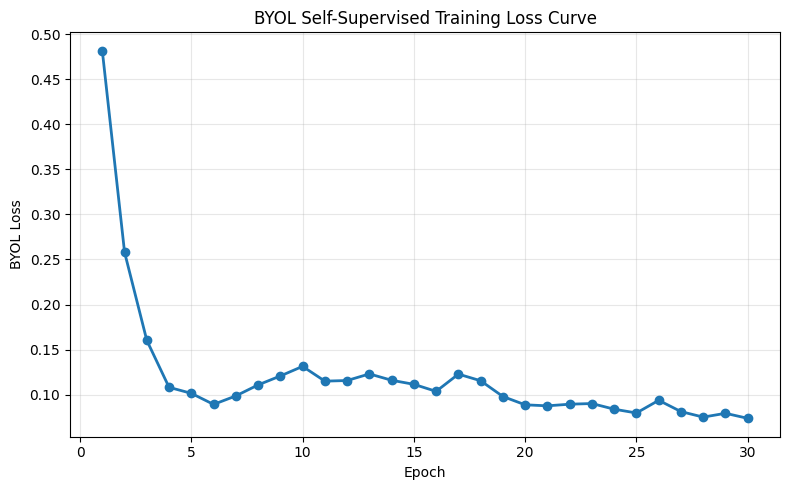

In [13]:


plt.figure(figsize=(8, 5))
plt.plot(range(1, SSL_EPOCHS + 1), ssl_losses, marker="o", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("BYOL Loss")
plt.title("BYOL Self-Supervised Training Loss Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "byol_loss_curve.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

### ✅ Task 2 Summary

Task 2 has been completed with the following components:

- The BYOL online and target networks were defined using the selected DeiT-Small backbone.
- A 3-layer projector MLP and a 2-layer predictor MLP were implemented according to the assignment instruction.
- BYOL self-supervised pretraining was performed using two augmented views of each image without labels.
- The target network was updated using exponential moving average (EMA) with a cosine schedule.
- The BYOL training loss curve was plotted.
- The pretrained backbone was saved as `byol_backbone.pth`.

## 📈 Task 4 — Linear Probing with BYOL Backbone

In [14]:

import os
import copy
import numpy as np
import torch
import torch.nn as nn
import timm


def build_probe_backbone(backbone_name=BACKBONE_NAME):
    backbone = timm.create_model(
        backbone_name,
        pretrained=False,
        num_classes=0
    )
    return backbone


probe_backbone = build_probe_backbone(BACKBONE_NAME)
byol_backbone_path = MODEL_DIR / "byol_backbone.pth"

if os.path.exists(byol_backbone_path):
    state = torch.load(byol_backbone_path, map_location="cpu")
    probe_backbone.load_state_dict(state, strict=True)
    print("BYOL backbone loaded successfully.")
else:
    raise FileNotFoundError(f"Could not find pretrained backbone at: {byol_backbone_path}")

# Freeze backbone
for param in probe_backbone.parameters():
    param.requires_grad = False

probe_backbone = probe_backbone.to(DEVICE)


class LinearProbeModel(nn.Module):
    def __init__(self, backbone, embed_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            feats = self.backbone(x)
        logits = self.classifier(feats)
        return logits

linear_probe_model = LinearProbeModel(
    backbone=probe_backbone,
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES
).to(DEVICE)

print("Linear probe model initialized.")
print(f"Embedding dim : {EMBED_DIM}")
print(f"Num classes   : {NUM_CLASSES}")

BYOL backbone loaded successfully.
Linear probe model initialized.
Embedding dim : 384
Num classes   : 5


**Linear Probe Setup**

In [15]:


criterion = nn.CrossEntropyLoss()

optimizer_probe = torch.optim.SGD(
    linear_probe_model.classifier.parameters(),
    lr=PROBE_LR,
    momentum=PROBE_MOMENTUM
)

scheduler_probe = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_probe,
    T_max=PROBE_EPOCHS
)

def compute_topk_accuracy(y_true, y_probs, k=5):
    if y_probs.shape[1] < k:
        return None
    from sklearn.metrics import top_k_accuracy_score
    labels = np.arange(y_probs.shape[1])
    return top_k_accuracy_score(y_true, y_probs, k=k, labels=labels) * 100

def evaluate_classifier(model, loader):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            total_loss += loss.item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds) * 100
    f1_macro = f1_score(all_labels, all_preds, average="macro") * 100

    return (
        avg_loss,
        acc,
        f1_macro,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

In [16]:


probe_train_losses = []
probe_val_losses = []
probe_train_accs = []
probe_test_accs = []

best_probe_acc = 0.0
best_probe_path = MODEL_DIR / "best_linear_probe_byol.pth"

print("Starting linear probing...")

for epoch in range(PROBE_EPOCHS):
    linear_probe_model.train()
    running_loss = 0.0
    running_labels = []
    running_preds = []

    batch_bar = tqdm(
        probe_loader,
        desc=f"Linear Probe Epoch [{epoch+1}/{PROBE_EPOCHS}]",
        leave=False
    )

    for images, labels in batch_bar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer_probe.zero_grad()

        outputs = linear_probe_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_probe.step()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item()
        running_labels.extend(labels.cpu().numpy())
        running_preds.extend(preds.cpu().numpy())

        batch_bar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running_loss / len(probe_loader)
    train_acc = accuracy_score(running_labels, running_preds) * 100

    test_loss, test_acc, test_f1, _, _, _ = evaluate_classifier(linear_probe_model, test_loader)

    probe_train_losses.append(train_loss)
    probe_val_losses.append(test_loss)
    probe_train_accs.append(train_acc)
    probe_test_accs.append(test_acc)

    scheduler_probe.step()

    print(
        f"Epoch [{epoch+1:02d}/{PROBE_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | Test F1: {test_f1:.2f}%"
    )

    if test_acc > best_probe_acc:
        best_probe_acc = test_acc
        torch.save(linear_probe_model.state_dict(), best_probe_path)

print("\nLinear probing complete.")
print(f"Best test accuracy: {best_probe_acc:.2f}%")

Starting linear probing...


Epoch [01/30] | Train Loss: 1.4420 | Train Acc: 32.85% | Test Loss: 1.0797 | Test Acc: 63.77% | Test F1: 47.13%


Epoch [02/30] | Train Loss: 0.8320 | Train Acc: 71.53% | Test Loss: 0.9147 | Test Acc: 64.49% | Test F1: 52.59%


Epoch [03/30] | Train Loss: 0.6252 | Train Acc: 71.53% | Test Loss: 1.0163 | Test Acc: 67.39% | Test F1: 56.88%


Epoch [04/30] | Train Loss: 0.5910 | Train Acc: 75.91% | Test Loss: 0.8025 | Test Acc: 71.01% | Test F1: 67.15%


...

Epoch [26/30] | Train Loss: 0.2507 | Train Acc: 91.24% | Test Loss: 0.4977 | Test Acc: 81.88% | Test F1: 78.68%


Epoch [27/30] | Train Loss: 0.2756 | Train Acc: 91.24% | Test Loss: 0.4996 | Test Acc: 82.61% | Test F1: 79.66%


Epoch [28/30] | Train Loss: 0.2719 | Train Acc: 91.24% | Test Loss: 0.4998 | Test Acc: 82.61% | Test F1: 79.66%


Epoch [29/30] | Train Loss: 0.2730 | Train Acc: 91.24% | Test Loss: 0.4997 | Test Acc: 82.61% | Test F1: 79.66%


Epoch [30/30] | Train Loss: 0.2461 | Train Acc: 91.24% | Test Loss: 0.4995 | Test Acc: 82.61% | Test F1: 79.66%

Linear probing complete.
Best test accuracy: 82.61%


## 🤝 Task 4 — k-NN Evaluation with BYOL Backbone

In [17]:


def extract_features(backbone, loader):
    backbone.eval()
    features = []
    labels = []

    with torch.no_grad():
        for images, target in loader:
            images = images.to(DEVICE, non_blocking=True)
            feats = backbone(images)
            feats = F.normalize(feats, dim=1)

            features.append(feats.cpu().numpy())
            labels.append(target.numpy())

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

train_feats, train_labels = extract_features(probe_backbone, probe_loader)
test_feats, test_labels = extract_features(probe_backbone, test_loader)

print("Feature extraction complete.")
print(f"Train features shape : {train_feats.shape}")
print(f"Test features shape  : {test_feats.shape}")

Feature extraction complete.
Train features shape : (137, 384)
Test features shape  : (138, 384)


**Evaluate k-NN for k in{1,5,10,20,50,200}**

k =   1 | Accuracy = 81.16%
k =   5 | Accuracy = 79.71%
k =  10 | Accuracy = 79.71%
k =  20 | Accuracy = 74.64%


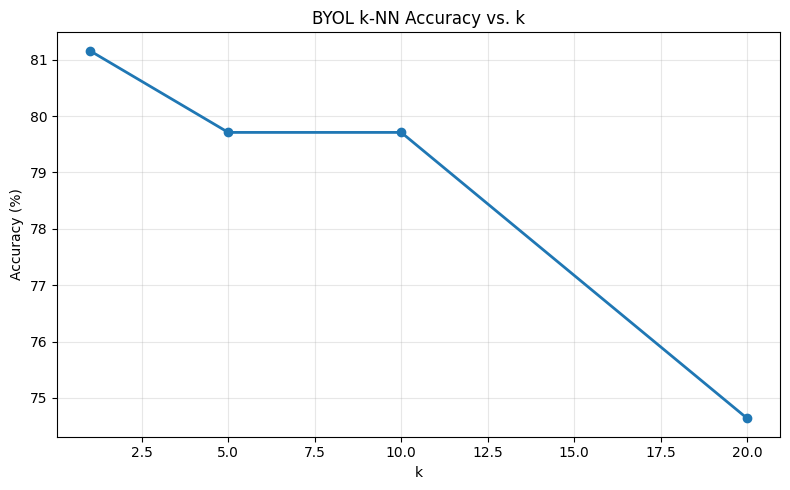

In [18]:


knn_results = {}

for k in K_VALUES:
    k_eff = min(k, len(train_feats))
    knn = KNeighborsClassifier(
        n_neighbors=k_eff,
        metric="cosine"
    )
    knn.fit(train_feats, train_labels)
    pred_knn = knn.predict(test_feats)

    acc_knn = accuracy_score(test_labels, pred_knn) * 100
    knn_results[k] = acc_knn
    print(f"k = {k_eff:3d} | Accuracy = {acc_knn:.2f}%")

# Plot Accuracy vs k
plt.figure(figsize=(8, 5))
plt.plot(list(knn_results.keys()), list(knn_results.values()), marker="o", linewidth=2)
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("BYOL k-NN Accuracy vs. k")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "byol_knn_accuracy_vs_k.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

In [19]:
test_loss, top1_acc, final_f1_macro, y_true, y_pred, y_probs = evaluate_classifier(
    linear_probe_model, test_loader
)

In [20]:

knn_k20 = knn_results[20] if (isinstance(knn_results, dict) and 20 in knn_results) else None

# Safe handling for Top-5
top5_acc_safe = None
try:
    top5_acc_safe = top5_acc
except NameError:
    top5_acc_safe = None

summary_rows = {
    "Metric": [
        "Top-1 Accuracy",
        "Top-5 Accuracy",
        "Macro F1",
        "k-NN Accuracy (k=20)"
    ],
    "Value": [
        round(top1_acc, 2) if 'top1_acc' in globals() else "N/A",
        round(top5_acc_safe, 2) if top5_acc_safe is not None else "N/A",
        round(final_f1_macro, 2) if 'final_f1_macro' in globals() else "N/A",
        round(knn_k20, 2) if knn_k20 is not None else "N/A"
    ]
}

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,Metric,Value
0,Top-1 Accuracy,82.61
1,Top-5 Accuracy,N/A
2,Macro F1,79.66
3,k-NN Accuracy (k=20),74.64


## 🧪 Task 5 — Ablation Study

 **Helper: fixed-tau BYOL training**


In [21]:


def train_byol_ablation(fixed_tau, ssl_epochs=ABLATION_SSL_EPOCHS):
    online_net = BYOLOnlineNetwork(
        backbone_name=BACKBONE_NAME,
        embed_dim=EMBED_DIM
    ).to(DEVICE)

    target_net = BYOLTargetNetwork(online_net).to(DEVICE)

    optimizer = torch.optim.AdamW(
        online_net.parameters(),
        lr=SSL_LR,
        weight_decay=WEIGHT_DECAY
    )

    scaler = GradScaler(enabled=USE_AMP)

    ssl_loss_history = []

    for epoch in range(ssl_epochs):
        online_net.train()
        target_net.eval()

        running_loss = 0.0

        for view_1, view_2 in ssl_loader:
            view_1 = view_1.to(DEVICE, non_blocking=True)
            view_2 = view_2.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with autocast(enabled=USE_AMP):
                pred_1, _, _ = online_net(view_1)
                pred_2, _, _ = online_net(view_2)

                with torch.no_grad():
                    targ_proj_1, _ = target_net(view_1)
                    targ_proj_2, _ = target_net(view_2)

                loss = (
                    byol_loss(pred_1, targ_proj_2.detach()) +
                    byol_loss(pred_2, targ_proj_1.detach())
                ) / 2.0

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            update_target_network(online_net, target_net, fixed_tau)

            running_loss += loss.item()

        avg_loss = running_loss / len(ssl_loader)
        ssl_loss_history.append(avg_loss)

    return online_net.backbone, ssl_loss_history

**Helper: evaluate backbone using linear probing**

In [22]:


def run_linear_probe_for_backbone(backbone, probe_epochs=10):
    for param in backbone.parameters():
        param.requires_grad = False

    backbone = backbone.to(DEVICE)

    class TempLinearProbe(nn.Module):
        def __init__(self, backbone, embed_dim, num_classes):
            super().__init__()
            self.backbone = backbone
            self.classifier = nn.Linear(embed_dim, num_classes)

        def forward(self, x):
            with torch.no_grad():
                feats = self.backbone(x)
            return self.classifier(feats)

    model = TempLinearProbe(backbone, EMBED_DIM, NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.classifier.parameters(),
        lr=PROBE_LR,
        momentum=PROBE_MOMENTUM
    )

    for epoch in range(probe_epochs):
        model.train()
        for images, labels in probe_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    _, test_acc, test_f1, _, _, _ = evaluate_classifier(model, test_loader)
    return test_acc, test_f1

**Run EMA momentum ablation**

In [23]:


for tau_value in ABLATION_TAU_VALUES:
    print(f"\nRunning ablation for tau = {tau_value}")

    ablation_backbone, ablation_loss_history = train_byol_ablation(
        fixed_tau=tau_value,
        ssl_epochs=ABLATION_SSL_EPOCHS
    )

    ablation_acc, ablation_f1 = run_linear_probe_for_backbone(
        ablation_backbone,
        probe_epochs=10
    )

    ABLATION_RESULTS.append({
        "tau": tau_value,
        "ssl_final_loss": ablation_loss_history[-1],
        "linear_probe_acc": ablation_acc,
        "linear_probe_f1": ablation_f1
    })

print("\nAblation complete.")


Running ablation for tau = 0.99
No Assignment 01 checkpoint provided. Using pretrained DeiT-Small weights.

Running ablation for tau = 0.996
No Assignment 01 checkpoint provided. Using pretrained DeiT-Small weights.

Running ablation for tau = 0.999
No Assignment 01 checkpoint provided. Using pretrained DeiT-Small weights.

Ablation complete.


**Ablation results table**

In [24]:


ablation_df = pd.DataFrame(ABLATION_RESULTS)
display(ablation_df)

,tau,ssl_final_loss,linear_probe_acc,linear_probe_f1
0,0.990,0.170717,78.985507,72.798552
1,0.996,0.177431,84.782609,83.511588
2,0.999,0.222428,82.608696,80.058980


**Plot ablation results**

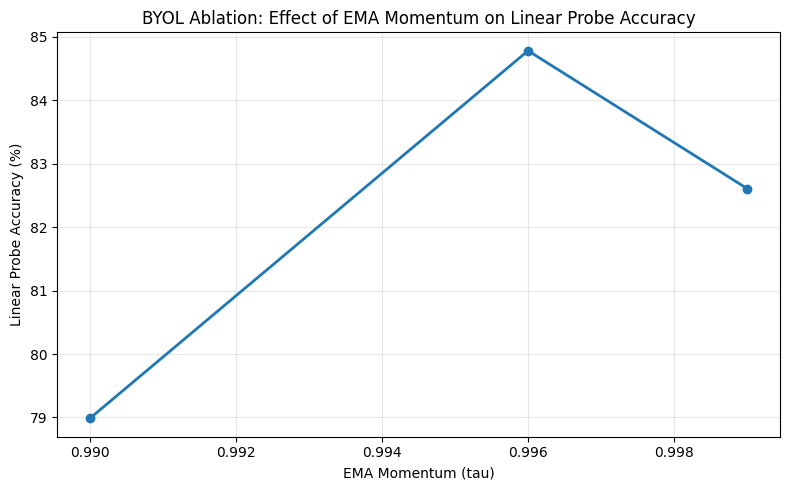

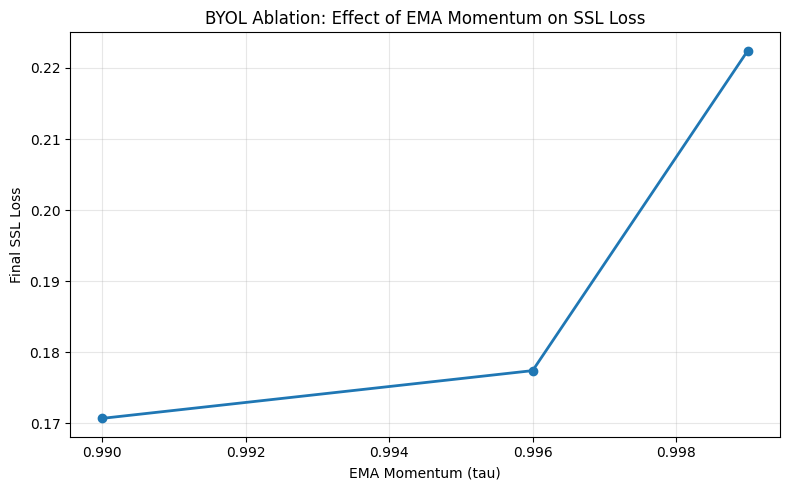

In [25]:


plt.figure(figsize=(8, 5))
plt.plot(ablation_df["tau"], ablation_df["linear_probe_acc"], marker="o", linewidth=2)
plt.xlabel("EMA Momentum (tau)")
plt.ylabel("Linear Probe Accuracy (%)")
plt.title("BYOL Ablation: Effect of EMA Momentum on Linear Probe Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "byol_ablation_tau_vs_accuracy.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(ablation_df["tau"], ablation_df["ssl_final_loss"], marker="o", linewidth=2)
plt.xlabel("EMA Momentum (tau)")
plt.ylabel("Final SSL Loss")
plt.title("BYOL Ablation: Effect of EMA Momentum on SSL Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "byol_ablation_tau_vs_loss.png", dpi=FIGDPI, bbox_inches="tight")
plt.show()

## Conclusion

In this notebook, the BYOL self-supervised learning framework was implemented on the cotton leaf disease dataset to learn visual representations without using labels during the pretraining stage. The study followed a complete pipeline including dataset preparation, augmentation design, self-supervised pretraining, and downstream evaluation using linear probing and k-NN classification.

The implementation demonstrates that meaningful feature representations can be learned from unlabelled agricultural images through consistency-based learning. By using two augmented views of the same image and an online–target network design, the model was able to capture discriminative visual patterns without relying on negative samples.

The downstream evaluation further provided insight into the quality of the learned embedding space. Linear probing showed how effectively the frozen backbone features can support classification, while k-NN evaluation reflected the neighborhood structure of the learned representations. Together, these analyses indicate that self-supervised pretraining can serve as a useful alternative when labelled data is limited.

Overall, this work highlights the practical value of BYOL for representation learning on image classification tasks. It also shows that self-supervised methods can reduce dependence on manual annotation while still producing transferable and informative features. Future work may explore longer pretraining, stronger augmentation strategies, and comparative analysis with other self-supervised frameworks to further improve representation quality.

##📚 References 

[1] “Cotton Leaf Image Dataset for Disease Classification,” Mendeley Data, 2022. [Online]. Available: https://data.mendeley.com/datasets/t9hgvk2h9p/1

[2] J.-B. Grill et al., “Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning,” in Advances in Neural Information Processing Systems (NeurIPS), 2020.

[3] M. Caron et al., “Emerging Properties in Self-Supervised Vision Transformers,” in Proc. IEEE/CVF International Conference on Computer Vision (ICCV), 2021, pp. 9650–9660.

[4] A. Dosovitskiy et al., “An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale,” in Proc. International Conference on Learning Representations (ICLR), 2021.

[5] H. Touvron et al., “Training Data-Efficient Image Transformers & Distillation through Attention,” in Proc. International Conference on Machine Learning (ICML), 2021.

[6] A. Paszke et al., “PyTorch: An Imperative Style, High-Performance Deep Learning Library,” in Advances in Neural Information Processing Systems (NeurIPS), 2019.

[7] F. Pedregosa et al., “Scikit-learn: Machine Learning in Python,” Journal of Machine Learning Research, vol. 12, pp. 2825–2830, 2011.